original | real=4894, AI-generated=3719, AUC=0.9949
transformed | real=4894, AI-generated=3719, AUC=0.9897
severely_transformed | real=4894, AI-generated=3719, AUC=0.9555


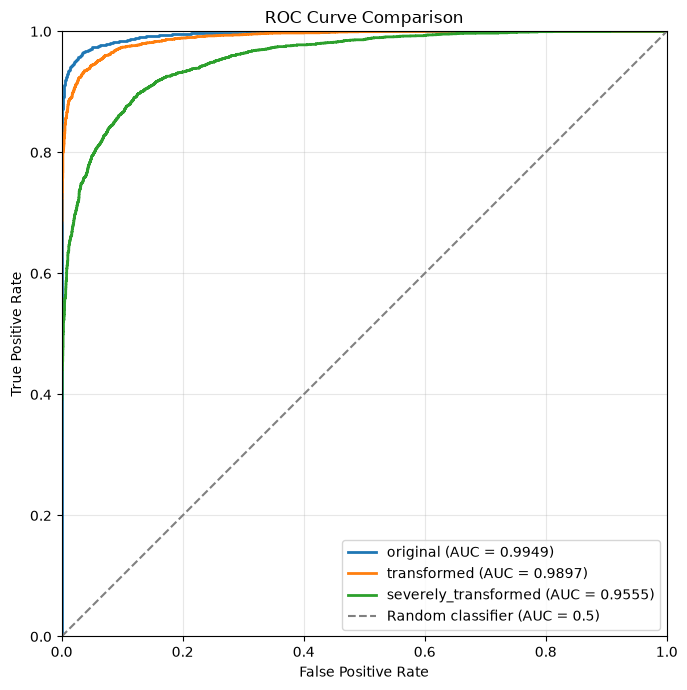

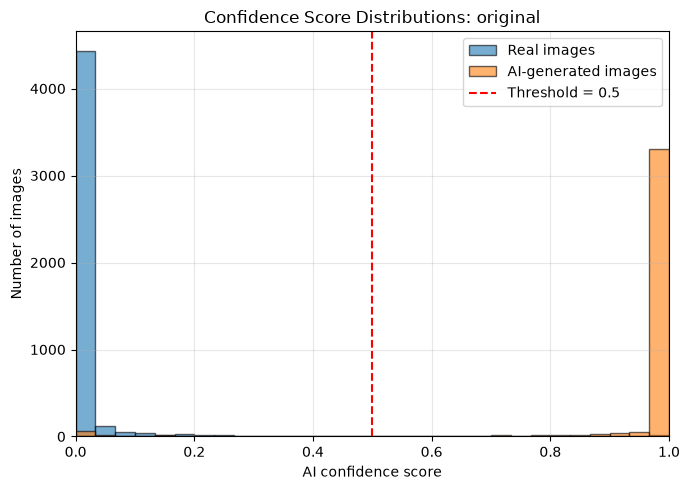

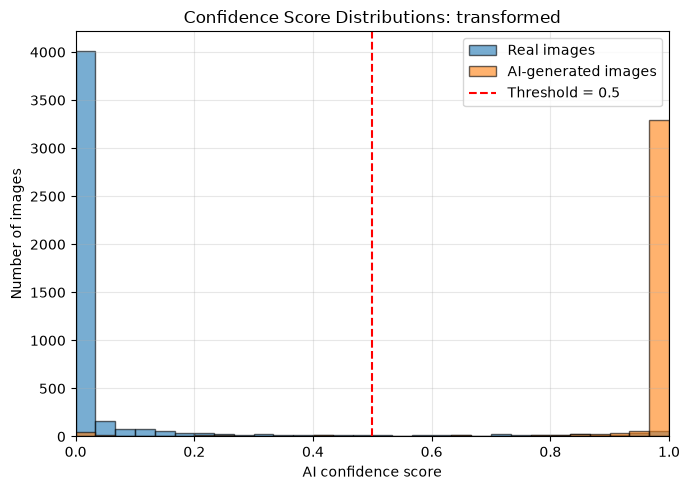

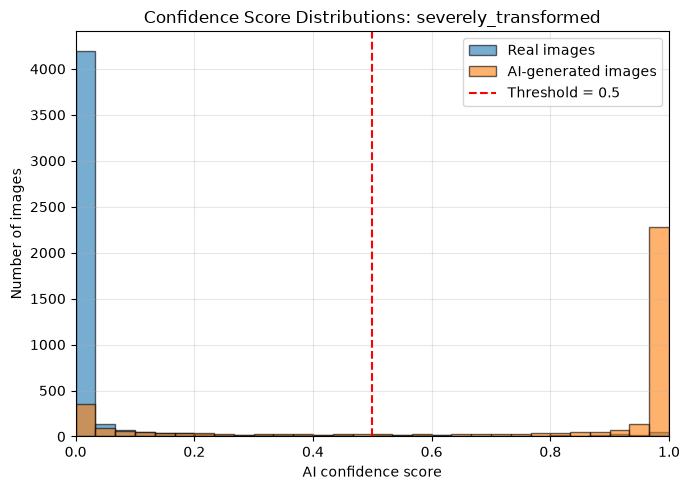

In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score


JSON_PATHS = [
    "original.json",
    "transformed.json",
    "severely_transformed.json",
]

# Names displayed in legends and graph titles.
PLOT_LABELS = [
    "original",
    "transformed",
    "severely_transformed",
]

THRESHOLD = 0.5
COMMON_BINS = np.linspace(0, 1, 31)


def load_predictions(json_path):
    """Load true labels and AI-confidence scores from one prediction file."""
    json_path = Path(json_path).expanduser()

    with json_path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    y_true = []
    y_score = []

    for item in data:
        filename = Path(item["image_path"]).name
        confidence = float(item["pred"])

        # COCO images are real (0); all other images are AI-generated (1).
        label = 0 if filename.startswith("coco2017val_") else 1

        y_true.append(label)
        y_score.append(confidence)

    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)

    if len(y_true) == 0:
        raise ValueError(f"No predictions found in {json_path}")

    if len(np.unique(y_true)) < 2:
        raise ValueError(
            f"{json_path} does not contain both classes. "
            "Check the filename-labeling rule."
        )

    if not np.all(np.isfinite(y_score)):
        raise ValueError(f"{json_path} contains non-finite confidence scores.")

    return y_true, y_score


def make_safe_filename(name):
    """Convert a plot label into a filesystem-safe filename component."""
    safe_name = "".join(
        character if character.isalnum() else "_"
        for character in name
    )
    return safe_name.strip("_") or "model"


def main():
    if len(JSON_PATHS) != 3:
        raise ValueError("JSON_PATHS must contain exactly three paths.")

    if len(PLOT_LABELS) != len(JSON_PATHS):
        raise ValueError(
            "PLOT_LABELS must contain one label for every JSON path."
        )

    results = []

    for json_path, plot_label in zip(JSON_PATHS, PLOT_LABELS):
        y_true, y_score = load_predictions(json_path)

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = roc_auc_score(y_true, y_score)

        real_count = int(np.sum(y_true == 0))
        ai_count = int(np.sum(y_true == 1))

        print(
            f"{plot_label} | "
            f"real={real_count}, "
            f"AI-generated={ai_count}, "
            f"AUC={roc_auc:.4f}"
        )

        results.append(
            {
                "label": plot_label,
                "y_true": y_true,
                "y_score": y_score,
                "fpr": fpr,
                "tpr": tpr,
                "roc_auc": roc_auc,
            }
        )

    # ------------------------------------------------------------------
    # Plot all three ROC curves in one graph.
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7, 7))

    for result in results:
        ax.plot(
            result["fpr"],
            result["tpr"],
            linewidth=2,
            label=(
                f"{result['label']} "
                f"(AUC = {result['roc_auc']:.4f})"
            ),
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Random classifier (AUC = 0.5)",
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve Comparison")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig("roc_curve_comparison.png", dpi=300)

    # ------------------------------------------------------------------
    # Plot one separate confidence-distribution graph per JSON file.
    # ------------------------------------------------------------------

    for index, result in enumerate(results, start=1):
        y_true = result["y_true"]
        y_score = result["y_score"]
        plot_label = result["label"]

        real_scores = y_score[y_true == 0]
        ai_scores = y_score[y_true == 1]

        fig, ax = plt.subplots(figsize=(7, 5))

        # Both classes use identical bin boundaries for a fair comparison.
        ax.hist(
            real_scores,
            bins=COMMON_BINS,
            alpha=0.6,
            edgecolor="black",
            label="Real images",
        )

        ax.hist(
            ai_scores,
            bins=COMMON_BINS,
            alpha=0.6,
            edgecolor="black",
            label="AI-generated images",
        )

        ax.axvline(
            THRESHOLD,
            color="red",
            linestyle="--",
            label=f"Threshold = {THRESHOLD}",
        )

        ax.set_xlim(0, 1)
        ax.set_xlabel("AI confidence score")
        ax.set_ylabel("Number of images")
        ax.set_title(f"Confidence Score Distributions: {plot_label}")
        ax.legend()
        ax.grid(alpha=0.3)

        fig.tight_layout()

        safe_label = make_safe_filename(plot_label)
        output_path = (
            f"confidence_distribution_{index}_{safe_label}.png"
        )
        fig.savefig(output_path, dpi=300)

    # Display the combined ROC graph and all three distribution graphs.
    plt.show()


if __name__ == "__main__":
    main()

In [2]:
import json
import shutil
from pathlib import Path


JSON_PATH = Path("original.json")
OUTPUT_JSON_PATH = Path("predictions_moved.json")

FP_DIR = Path("fp")
FN_DIR = Path("fn")

CLASSIFICATION_THRESHOLD = 0.5
MOVE_THRESHOLD = 0.8


def unique_destination(directory, source, index):
    """Return a destination that will not overwrite an existing file."""
    destination = directory / source.name

    if not destination.exists():
        return destination

    attempt = 0

    while True:
        extra_suffix = "" if attempt == 0 else f"_{attempt}"
        destination = directory / (
            f"{source.stem}_{index:07d}{extra_suffix}{source.suffix}"
        )

        if not destination.exists():
            return destination

        attempt += 1


FP_DIR.mkdir(parents=True, exist_ok=True)
FN_DIR.mkdir(parents=True, exist_ok=True)

with JSON_PATH.open("r", encoding="utf-8") as file:
    data = json.load(file)


predicted_ai_count = sum(
    float(item["pred"]) >= CLASSIFICATION_THRESHOLD
    for item in data
)

moved_count = 0
false_positive_count = 0
false_negative_count = 0

for index, item in enumerate(data):
    probability = float(item["pred"])
    source = Path(item["image_path"])

    # COCO images are treated as real; everything else is treated as AI.
    is_real = source.name.lower().startswith("coco")

    if is_real:
        # High-confidence AI prediction for a real image: false positive.
        should_move = probability > MOVE_THRESHOLD
        destination_directory = FP_DIR
        error_type = "false positive"
    else:
        # High-confidence real prediction for an AI image: false negative.
        should_move = probability < (1.0 - MOVE_THRESHOLD)
        destination_directory = FN_DIR
        error_type = "false negative"

    if not should_move:
        continue

    if not source.is_file():
        print(f"Missing image, skipped: {source}")
        continue

    destination = unique_destination(
        destination_directory,
        source,
        index,
    )

    shutil.move(str(source), str(destination))
    item["image_path"] = str(destination)
    moved_count += 1

    if is_real:
        false_positive_count += 1
    else:
        false_negative_count += 1

    print(
        f"Moved {error_type}: {source} -> {destination} "
        f"(AI score={probability:.4f})"
    )


total = len(data)
predicted_ai_ratio = predicted_ai_count / total if total else 0.0

with OUTPUT_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(data, file, indent=2)


print(f"Predicted AI: {predicted_ai_count}/{total}")
print(f"AI ratio: {predicted_ai_ratio:.2%}")
print(f"High-confidence false positives moved: {false_positive_count}")
print(f"High-confidence false negatives moved: {false_negative_count}")
print(f"Total moved: {moved_count}")
print(f"Updated JSON saved to: {OUTPUT_JSON_PATH}")

Moved false positive: data/clean_for_demo/coco2017val_img159015.jpg -> fp/coco2017val_img159015.jpg (AI score=0.9002)
Moved false positive: data/clean_for_demo/coco2017val_img159047.jpg -> fp/coco2017val_img159047.jpg (AI score=0.8075)
Moved false positive: data/clean_for_demo/coco2017val_img159091.jpg -> fp/coco2017val_img159091.jpg (AI score=0.8613)
Moved false positive: data/clean_for_demo/coco2017val_img159146.jpg -> fp/coco2017val_img159146.jpg (AI score=0.8166)
Moved false positive: data/clean_for_demo/coco2017val_img159175.jpg -> fp/coco2017val_img159175.jpg (AI score=0.9972)
Moved false positive: data/clean_for_demo/coco2017val_img159725.jpg -> fp/coco2017val_img159725.jpg (AI score=0.9122)
Moved false positive: data/clean_for_demo/coco2017val_img159775.jpg -> fp/coco2017val_img159775.jpg (AI score=0.9767)
Moved false positive: data/clean_for_demo/coco2017val_img159996.jpg -> fp/coco2017val_img159996.jpg (AI score=0.8999)
Moved false positive: data/clean_for_demo/coco2017val_im